In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

import unicodedata, re, os, random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TerminateOnNaN
import keras_tuner as kt

In [5]:
path = r'C:\Users\agrom\OneDrive\Desktop\CodigoTesis\Datos_Tesis_SW.csv'
df = pd.read_csv(path)
df.describe(include='all')

,Datetime,RotorSpeed,WindSpeed,PowerOutput,PitchDeg_Mean,temperature_2m,wind_speed_10m,wind_direction_10m,direct_radiation_instant,surface_pressure,relative_humidity_2m
count,11912,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000,11912.000000
unique,11912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-12-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,21.783351,2.528212,0.973767,31.599770,9.767231,2.723572,160.952363,98.335195,959.145997,75.309743
std,NaN,21.836371,2.169191,1.701793,20.093799,7.917434,1.544116,91.922277,181.531746,7.182381,16.856661
min,NaN,0.000000,0.000000,-0.043153,14.034000,-7.200000,0.000000,1.636545,0.000000,926.156900,23.955673
25%,NaN,0.000278,1.086410,0.000000,14.646029,3.650000,1.612452,62.102830,0.000000,955.489137,63.822680
50%,NaN,16.098900,1.944064,0.109803,26.571437,9.050000,2.469818,180.000000,0.000000,959.299215,78.740165
75%,NaN,38.949664,3.360289,1.019128,38.191855,15.450000,3.569313,235.713070,106.305447,963.233150,89.509480


In [6]:
# 1. Asegurarnos de que Datetime sea realmente tiempo y esté como columna
# Si Datetime es tu índice, lo bajamos a columna primero
if df.index.name == 'Datetime' or 'Datetime' not in df.columns:
    df = df.reset_index()

# 2. Convertir a tipo datetime (por si acaso)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Dia Juliano'] = df['Datetime'].apply(lambda x: x.toordinal())

print("Datos originales:", len(df))
# Supongamos que tu dataframe es df con columnas 'Datetime' y 'WindSpeed'
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Definir fecha de corte
fecha_corte = pd.to_datetime("2023-01-01")

# Filtrar datos posteriores a esa fecha
df = df[df['Datetime'] >= fecha_corte].reset_index(drop=True)


print("Datos filtrados:", len(df))


Datos originales: 11912
Datos filtrados: 4626


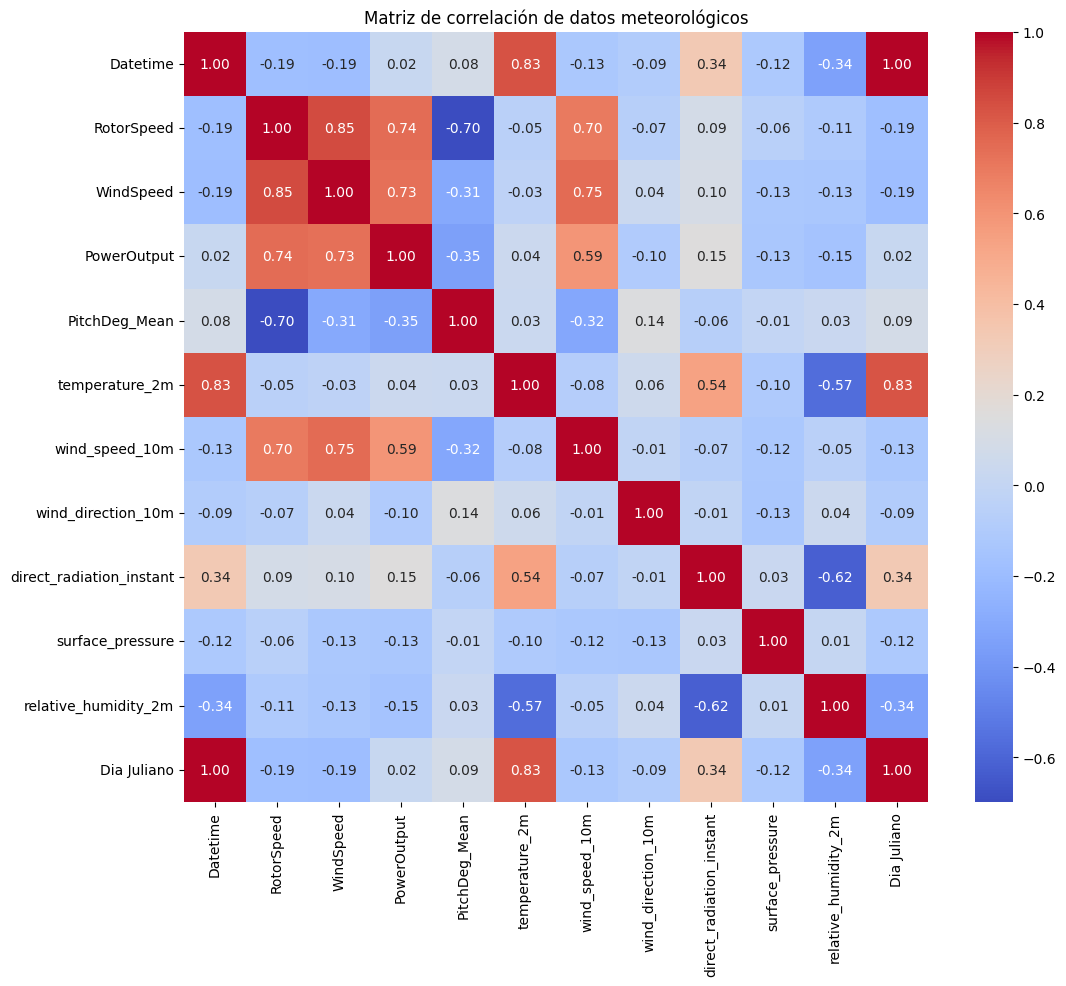

In [8]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación de datos meteorológicos')
plt.show()

## Regresión Lineal Múltiple
A continuación se empleará un modelo de regresión lineal múltiple con el fin de verificar si se puede modelar como relaciones lineales, lo cual sabemos por estudios que el viento es aleatorio y no se mueve linealmente. Esto es para saber las variables significativas linealmente y para dar inicio a análisis más avanzados como ramdon forest para ver relaciones no lineales y luego empezar con el modelo de predicción

In [9]:
dependent_variable = 'WindSpeed'
#dependent_variable = 'WindSpeed'
independent_variables = [col for col in df.columns if col not in ['Datetime', 'RotorSpeed','PowerOutput', 'PitchDeg_Mean', 'wind_speed_10m', dependent_variable, 'index']]
#independent_variables = [col for col in df.columns if col not in ['Datetime', 'RotorSpeed','PowerOutput', 'PitchDeg_Mean', 'wind_speed_10m', dependent_variable]]
X = df[independent_variables]
X = sm.add_constant(df[independent_variables])
y = df[dependent_variable]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              WindSpeed   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     110.2
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.67e-130
Time:                        19:03:08   Log-Likelihood:                -9582.5
No. Observations:                4626   AIC:                         1.918e+04
Df Residuals:                    4619   BIC:                         1.922e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [10]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF) for Independent Variables:")
print(vif_data)

Variance Inflation Factor (VIF) for Independent Variables:
                    feature           VIF
0                     const  6.126780e+08
1            temperature_2m  5.248214e+00
2        wind_direction_10m  1.119608e+00
3  direct_radiation_instant  1.821920e+00
4          surface_pressure  1.043362e+00
5      relative_humidity_2m  1.985908e+00
6               Dia Juliano  3.811216e+00



 Optimizando modelo para ventana de 1 horas...


c:\Users\agrom\OneDrive\Desktop\CodigoTesis\ThesisCode\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 Optimizando modelo para ventana de 3 horas...


c:\Users\agrom\OneDrive\Desktop\CodigoTesis\ThesisCode\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 Optimizando modelo para ventana de 6 horas...


...

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Optimizando modelo para ventana de 48 horas...


c:\Users\agrom\OneDrive\Desktop\CodigoTesis\ThesisCode\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 Optimizando modelo para ventana de 72 horas...


c:\Users\agrom\OneDrive\Desktop\CodigoTesis\ThesisCode\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 RESULTADOS GLOBALES
             Units  Dropout Activation  Learning Rate       MSE     MAE  \
Ventana (h)                                                               
1               96      0.1       relu          0.001   12.6467  2.9291   
3               48      0.3       relu          0.001  159.5002  9.7711   
6               32      0.1       tanh          0.001    4.2383  1.6744   
24             112      0.1       tanh          0.010    3.3296  1.4577   
48              32      0.4       tanh          0.010    1.5984  1.0199   
72              80      0.1       tanh          0.010    3.0179  1.3821   

                   R²  
Ventana (h)            
1             -7.1594  
3           -101.9341  
6             -1.7352  
24            -1.1484  
48            -0.0301  
72            -0.9398  


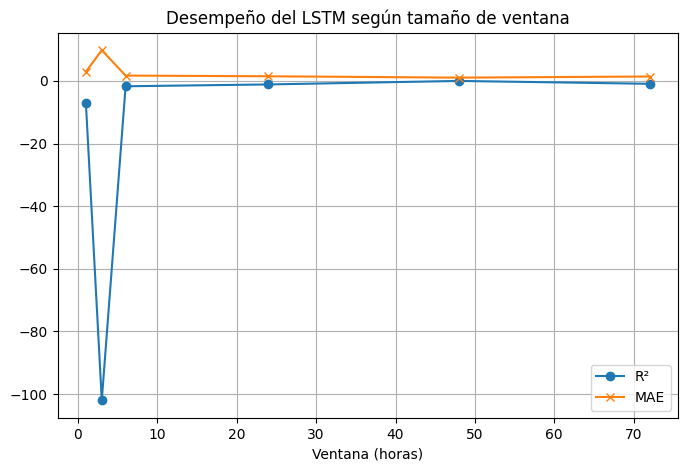

In [8]:
# Reproducibilidad
os.environ['PYTHONHASHSEED']='0'
os.environ['TF_DETERMINISTIC_OPS']='1'
seed=42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)


def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

def build_model(hp):
    """Define el espacio de búsqueda de hiperparámetros"""
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', 16, 128, step=16),
        activation=hp.Choice('activation', ['relu', 'tanh']),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=hp.Choice('learning_rate', [1e-4, 1e-3, 1e-2]))
    model.compile(optimizer=optimizer, loss='mse')
    return model

X = df[independent_variables].values
y = df[dependent_variable].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# BUCLE PARA TODAS LAS VENTANAS
window_sizes = [1, 3, 6, 24, 48, 72]
results_list = []

for time_steps in window_sizes:
    print(f"\n Optimizando modelo para ventana de {time_steps} horas...")

    # Crear secuencias
    X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

    # División temporal (sin shuffle)
    train_size = int(len(X_seq) * 0.7)
    val_size = int(len(X_seq) * 0.15)
    test_start = train_size + val_size
    X_train, X_val, X_test = X_seq[:train_size], X_seq[train_size:test_start], X_seq[test_start:]
    y_train, y_val, y_test = y_seq[:train_size], y_seq[train_size:test_start], y_seq[test_start:]

    # Configurar tuner
    tuner = kt.RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=5,
        executions_per_trial=2,
        overwrite=True,
        directory='tuner_results',
        project_name=f'lstm_sw_window_{time_steps}'
    )

    tuner.search(X_train, y_train, epochs=20, batch_size=32,
                 validation_data=(X_val, y_val), shuffle=False, verbose=0)

    # Obtener mejores hiperparámetros
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_units = best_hps.get('units')
    best_lr = best_hps.get('learning_rate')
    best_dropout = best_hps.get('dropout')
    best_act = best_hps.get('activation')

    # Entrenar modelo final con los mejores hiperparámetros
    best_model = tuner.hypermodel.build(best_hps)
    history = best_model.fit(
        X_train, y_train,
        epochs=100, batch_size=32,
        validation_data=(X_val, y_val),
        shuffle=False, verbose=0
    )

    # Evaluar en test
    y_pred = best_model.predict(X_test).flatten()
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Guardar resultados
    results_list.append({
        'Ventana (h)': time_steps,
        'Units': best_units,
        'Dropout': best_dropout,
        'Activation': best_act,
        'Learning Rate': best_lr,
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    })

# RESULTADOS FINALES
res_df = pd.DataFrame(results_list).set_index('Ventana (h)')
print("\n RESULTADOS GLOBALES")
print(res_df.round(4))

# Guardar en Excel
res_df.to_excel(r"C:\Users\agrom\OneDrive\Desktop\CodigoTesis\Resultados_Hiperparametros_LSTMCL.xlsx")

# Gráfico comparativo
plt.figure(figsize=(8,5))
plt.plot(res_df.index, res_df['R²'], marker='o', label='R²')
plt.plot(res_df.index, res_df['MAE'], marker='x', label='MAE')
plt.title('Desempeño del LSTM según tamaño de ventana')
plt.xlabel('Ventana (horas)')
plt.legend()
plt.grid(True)
plt.show()

Trial 30 Complete [00h 00m 21s]
val_loss: 0.019081635400652885

Best val_loss So Far: 0.016320697963237762
Total elapsed time: 00h 14m 38s
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
VENTANA 72h -> R2: -0.7654

TABLA FINAL:
                   R²       MAE
Ventana (h)                    
1           -0.066294  1.055318
6            0.000835  1.009678
24          -0.292736  1.107989
48          -0.006198  1.016780
72          -0.765417  1.262524


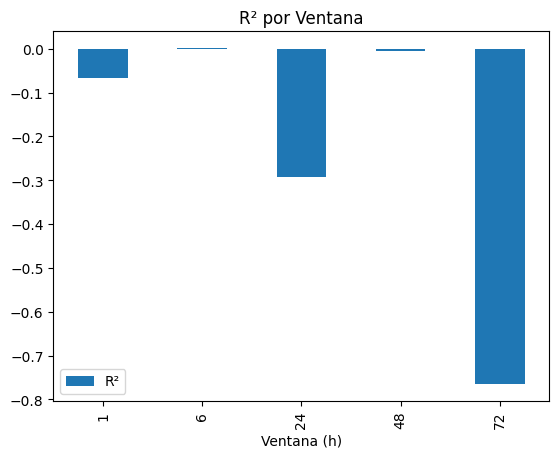

In [21]:
from sklearn.preprocessing import MinMaxScaler

# --- 1. PREPARACIÓN PREVIA ---
# Usamos MinMaxScaler para forzar estabilidad (0 a 1)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df[independent_variables]).astype('float32')
y_scaled = scaler_y.fit_transform(df[[dependent_variable]]).flatten().astype('float32')

def build_model(hp):
    model = Sequential()
    # Una sola capa potente suele ser más rápida y estable para estos casos
    model.add(LSTM(
        units=hp.Int('units', 32, 128, step=32),
        activation='tanh',
        input_shape=(None, X_scaled.shape[1]) # Acepta cualquier ventana
    ))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.3)))
    model.add(Dense(1))
    
    # LR un poco más alto para que aprenda rápido
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model

# --- 2. BUCLE DE VENTANAS ---
window_sizes = [1, 6, 24, 48, 72] # Te sugiero estas tres para ir al grano
results_list = []

for time_steps in window_sizes:
    print(f"\n >>> Iniciando Hyperband para ventana de {time_steps}h...")

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)
    
    split = int(len(X_seq) * 0.8)
    X_train, y_train = X_seq[:split], y_seq[:split]
    X_test, y_test = X_seq[split:], y_seq[split:]

    # Configurar Hyperband
    tuner = kt.Hyperband(
        build_model,
        objective='val_loss',
        max_epochs=15,
        factor=3,
        directory='hb_windows',
        project_name=f'win_{time_steps}',
        overwrite=True
    )

    # Búsqueda rápida
    tuner.search(X_train, y_train, epochs=10, validation_split=0.2, 
                 callbacks=[EarlyStopping(patience=3)], verbose=1)

    # Entrenar el mejor modelo de esa ventana
    best_hps = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.hypermodel.build(best_hps)
    best_model.fit(X_train, y_train, epochs=20, verbose=0)

    # Evaluación con DES-ESCALADO
    y_pred_scaled = best_model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"VENTANA {time_steps}h -> R2: {r2:.4f}")

    results_list.append({'Ventana (h)': time_steps, 'R²': r2, 'MAE': mae})

# --- 3. RESULTADOS Y GRÁFICO ---
res_df = pd.DataFrame(results_list).set_index('Ventana (h)')
print("\nTABLA FINAL:")
print(res_df)

res_df[['R²']].plot(kind='bar', title='R² por Ventana')
plt.show()